In [111]:
!pip install pyotp mplfinance pandas_ta fyers_apiv3 pygame stable-baselines3 gymnasium shimmy optuna

In [112]:
import requests
import base64
from datetime import datetime, timedelta, date
from datetime import time as dt_time
import time
import threading
import pyotp
from pytz import timezone
import pandas as pd
import numpy as np
from urllib.parse import urlparse, parse_qs
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import mplfinance as mpf
import pandas_ta as ta
import pygame
import os
import pytz
import json
import re
import random
import pickle

import gymnasium as gym
from gymnasium import spaces
from IPython.display import display, clear_output
from tqdm.notebook import tqdm

from fyers_apiv3 import fyersModel
from fyers_apiv3.FyersWebsocket import data_ws

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Dense, LSTM, GRU, Dropout, Attention, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.callbacks import Callback, ModelCheckpoint
from scipy.signal import argrelextrema
import tensorflow as tf
from collections import deque
from tensorflow import keras
from tensorflow.keras import layers, optimizers, models
from scipy.signal import find_peaks

In [113]:
def get_index_symbol_and_quantity(index):

    # Dictionary mapping index name to index symbols
    index_symbols = {
        'Bankex': 'BSE:BANKEX-INDEX',
        'Finnifty': 'NSE:FINNIFTY-INDEX',
        'Bank Nifty': 'NSE:NIFTYBANK-INDEX',
        'Nifty': 'NSE:NIFTY50-INDEX',
        'Sensex': 'BSE:SENSEX-INDEX'
    }

    # Determine the index symbol for the given index
    index_symbol = index_symbols.get(index, 'Invalid Index')

    # Determine the quantity based on the index symbol
    if index_symbol == "NSE:NIFTY50-INDEX":
        quantity = 25  # 25 is one lot for Nifty
    elif index_symbol == "NSE:NIFTYBANK-INDEX":
        quantity = 15  # 15 is one lot for Bank Nifty
    elif index_symbol == "NSE:FINNIFTY-INDEX":
        quantity = 40  # 40 is one lot for Finnifty
    elif index_symbol == "BSE:SENSEX-INDEX":
        quantity = 20  # 20 is two lot for Sensex
    elif index_symbol == "BSE:BANKEX-INDEX":
        quantity = 15  # 15 is one lot for Bankex
    else:
        quantity = 0  # Default value if none of the conditions match

    return index_symbol, quantity

In [114]:
app_id = "TS79V3NXK1-100"
secret_key = "KQCPB0FJ74"
redirect_uri = "https://google.com"
fyers_user = "XM22383"
fyers_pin = "4628"
fyers_totp = "EAQD6K4IUYOEGPJNVE6BMPTUSDCWIOHW"
response_type = "code"
state = "sample_state"
grant_type = "authorization_code"

fyers = None
fyers_socket = None

index_symbol, quantity = get_index_symbol_and_quantity("Bank Nifty")

interval_minutes = 2 # Set the interval to 1, 5, or 15 minutes

ist_timezone = pytz.timezone("Asia/Kolkata")

#Variables
ce_ltp = 0
pe_ltp = 0
index_ltp = 0
buy_sell_checked = False
ce_strike = None
pe_strike = None
ce_symbol = None
pe_symbol = None

target = 80
trailing_sl = 40

brokerage = 100

fixed_ltp = 0
fixed_index_ltp = 0
prev_ltp = 0
target_inside = 0
target_index_inside = 0
trailing_sl_inside = 0
trailing_index_inside = 0

active_order = False

sl_hit_condition = False
total_loss = 0
total_profit = 0
overall_win = 0
overall_loss = 0
total_points = 0

unsubscribe_done = False

active_order_sleep = 1

In [115]:
session = fyersModel.SessionModel(
    client_id=app_id,
    secret_key=secret_key,
    redirect_uri=redirect_uri,
    response_type=response_type,
    grant_type=grant_type
)

def getEncodedString(string):
    string = str(string)
    base64_bytes = base64.b64encode(string.encode("ascii"))
    return base64_bytes.decode("ascii")

if session is not None:
    session.generate_authcode()

    url_send_login_otp = "https://api-t2.fyers.in/vagator/v2/send_login_otp_v2"
    res = requests.post(url=url_send_login_otp, json={"fy_id": getEncodedString(fyers_user), "app_id": "2"}).json()

    if datetime.now().second % 30 > 27:
        time.sleep(5)

    url_verify_otp = "https://api-t2.fyers.in/vagator/v2/verify_otp"
    res2 = requests.post(url=url_verify_otp, json={"request_key": res["request_key"], "otp": pyotp.TOTP(fyers_totp).now()}).json()

    ses = requests.Session()
    url_verify_otp2 = "https://api-t2.fyers.in/vagator/v2/verify_pin_v2"
    payload2 = {"request_key": res2["request_key"], "identity_type": "pin", "identifier": getEncodedString(fyers_pin)}
    res3 = ses.post(url=url_verify_otp2, json=payload2).json()

    ses.headers.update({'authorization': f"Bearer {res3['data']['access_token']}"})

    tokenurl = "https://api-t1.fyers.in/api/v3/token"
    payload3 = {
        "fyers_id": fyers_user,
        "app_id": app_id[:-4],
        "redirect_uri": redirect_uri,
        "appType": "100",
        "code_challenge": "",
        "state": "None",
        "scope": "",
        "nonce": "",
        "response_type": "code",
        "create_cookie": True
    }

    res3 = ses.post(url=tokenurl, json=payload3).json()

    url = res3['Url']
    parsed = urlparse(url)
    auth_code = parse_qs(parsed.query)['auth_code'][0]

    session.set_token(auth_code)

    auth_response = session.generate_token()
    access_token = auth_response["access_token"]

    fyers = fyersModel.FyersModel(client_id=app_id, token=access_token)

    ws_token = app_id + ":" + access_token
    fyers_socket = data_ws.FyersDataSocket(access_token=ws_token, log_path="")

pd.DataFrame(fyers.get_profile())

,s,code,message,data
fy_id,ok,200,,XM22383
name,ok,200,,MARSHAL TUDU
image,ok,200,,https://myaccount-docs-prod.fyers.in/Profile_P...
display_name,ok,200,,None
pin_change_date,ok,200,,25-09-2023 17:16:16
email_id,ok,200,,iammarshal22@gmail.com
pwd_change_date,ok,200,,01-06-2022 20:36:31
PAN,ok,200,,---------
mobile_number,ok,200,,8458060663
totp,ok,200,,True


In [116]:
def fetch_candle_data(number):
    while True:
        try:
            today = date.today()
            yesterday = today - timedelta(number)

            data = {
                "symbol": index_symbol,
                "resolution": interval_minutes,
                "date_format": "1",
                "range_from": yesterday,
                "range_to": today,
                "cont_flag": "1"
            }

            result = fyers.history(data=data)

            if result is not None:
                train_df = pd.DataFrame(result['candles'], columns=['datetime', 'open', 'high', 'low', 'close', 'volume'])
                return train_df
        except Exception as e:
            print(f"Error fetching Candle Data: {e}")
            time.sleep(active_order_sleep)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [117]:
def fetch_train_candle_data(days_count):
    train_df = pd.DataFrame()

    while True:
        try:
            date_increment = 100
            for i in range(days_count):
                today = date.today() - timedelta(date_increment)
                yesterday = today - timedelta(100)

                data = {
                    "symbol": index_symbol,
                    "resolution": interval_minutes,
                    "date_format": "1",
                    "range_from": yesterday,
                    "range_to": today,
                    "cont_flag": "1"
                }

                result = fyers.history(data=data)

                if result is not None:
                    temp_df = pd.DataFrame(result['candles'], columns=['datetime', 'open', 'high', 'low', 'close', 'volume'])
                    train_df = pd.concat([temp_df, train_df], ignore_index=True)

                date_increment += 100

            if train_df is not None:
                return train_df

        except Exception as e:
            print(f"Error fetching Candle Data: {e}")
            time.sleep(active_order_sleep)

In [118]:
train_df = fetch_candle_data(100)

#train_df = fetch_train_candle_data(15)

print(len(train_df))

train_df = train_df.drop_duplicates(subset='datetime', keep='first')

print(len(train_df))

12439
12439


In [160]:
peak_length = 14
indicator_length = 14

class DataProcessor:
    def __init__(self, df, peak_length=14, indicator_length=14, live_processing=False):
        """
        Initialize the DataProcessor with separate lengths for peak detection and indicators.
        :param df: Input DataFrame with OHLC data.
        :param peak_length: Length used for peak detection (support/resistance).
        :param indicator_length: Length used for technical indicators.
        """
        self.df = df.copy()
        self.peak_length = peak_length  # Length for support and resistance peaks
        self.indicator_length = indicator_length  # Length for indicators like RSI, EMA, ATR
        self.live_processing = live_processing # Enable or disable live processing

    def preprocess_datetime(self):
        """
        Preprocess the datetime column: convert to IST and handle duplicates or missing values.
        """
        ist = timezone('Asia/Kolkata')
        self.df['datetime'] = pd.to_datetime(self.df['datetime'], unit='s')
        self.df['datetime'] = (
            self.df['datetime']
            .dt.tz_localize('UTC')
            .dt.tz_convert(ist)
            .dt.tz_localize(None)
        )

        if self.df['datetime'].duplicated().any() or self.df['datetime'].isnull().any():
            raise ValueError("The 'datetime' column contains duplicates or missing values.")

        self.df.set_index(self.df['datetime'], inplace=True)
        self.df.drop(['datetime'], axis=1, inplace=True, errors='ignore')
        return self

    def clean_data(self):
        """
        Handle volume column and remove rows with missing or zero values.
        """
        if 'volume' in self.df.columns:
            self.df['volume'] = self.df['volume'].fillna(0)
            if (self.df['volume'] == 0).all() or self.df['volume'].isnull().all():
                self.df.drop(['volume'], axis=1, inplace=True, errors='ignore')
        return self

    def add_indicators(self):
        """
        Add technical indicators dynamically based on the provided indicator length.
        """
        self.df['rsi'] = ta.rsi(self.df['close'], length=self.indicator_length)
        self.df['ema'] = ta.ema(self.df['close'], length=self.indicator_length)
        self.df['atr'] = ta.atr(self.df['high'], self.df['low'], self.df['close'], length=self.indicator_length)

        bbands = ta.bbands(self.df['close'], length=self.indicator_length)
        self.df['bb_upper'] = bbands['BBU_' + str(self.indicator_length) + '_2.0']
        self.df['bb_middle'] = bbands['BBM_' + str(self.indicator_length) + '_2.0']
        self.df['bb_lower'] = bbands['BBL_' + str(self.indicator_length) + '_2.0']

        self.df['hv'] = self.df['close'].pct_change().rolling(self.indicator_length).std() * (252 ** 0.5)
        self.df['price_spread'] = (self.df['close'] - self.df['open']) / (
            self.df['high'] - self.df['low'])
        self.df['candle_to_atr'] = (self.df['high'] - self.df['low']) / self.df['atr']
        self.df['hour'] = self.df.index.hour
        self.df['day_of_week'] = self.df.index.dayofweek
        self.df['roc'] = ta.roc(self.df['close'], length=self.indicator_length)
        self.df['price_change'] = self.df['close'].diff()
        self.df['Target'] = self.df['atr'] * 2
        self.df['Stop Loss'] = self.df['atr']
        return self

    def calculate_support_resistance(self):
        """
        Calculate support and resistance levels using peaks detection with separate peak_length.
        """
        resistance_peaks, _ = find_peaks(self.df['high'], distance=self.peak_length)
        self.df['resistance'] = 0.0
        self.df.loc[self.df.index[resistance_peaks], 'resistance'] = self.df['high'].iloc[resistance_peaks]

        support_peaks, _ = find_peaks(-self.df['low'], distance=self.peak_length)
        self.df['support'] = 0.0
        self.df.loc[self.df.index[support_peaks], 'support'] = self.df['low'].iloc[support_peaks]
        return self

    def detect_market_conditions(self):
        """
        Add features to detect market conditions (trending, range-bound, or volatile).
        """
        adx = ta.adx(self.df['high'], self.df['low'], self.df['close'], length=self.indicator_length)
        self.df['adx'] = adx['ADX_' + str(self.indicator_length)]

        self.df['rsi_oscillation'] = ((self.df['rsi'] > 40) & (self.df['rsi'] < 60)).astype(int)

        self.df['compression_ratio'] = self.df['atr'] / (
            self.df['high'].rolling(self.indicator_length).max()
            - self.df['low'].rolling(self.indicator_length).min()
        )
        return self

    def detect_market_regime(self):
        """
        Efficiently detect market regimes and assign integer labels:
        0 - Sideways, 1 - Trending, 2 - Volatile
        """
        self.df['market_regime'] = 0

        trending_threshold = 25
        self.df.loc[self.df['adx'] > trending_threshold, 'market_regime'] = 1

        self.df.loc[
            (self.df['bb_upper'] - self.df['bb_lower']) / self.df['bb_middle'] > 0.05,
            'market_regime'
        ] = 2
        return self

    def label_signals(self):
        """
        Generate buy/sell signals based on target and stop-loss levels.
        """
        self.df['Signal'] = 0
        self.df['Entry Price'] = 0.0
        self.df['Exit Price'] = 0.0

        for i in range(len(self.df)):
            entry_price = self.df['close'].iloc[i]

            target = self.df['Target'].iloc[i]
            stop_loss = self.df['Stop Loss'].iloc[i]

            buy_target_price = entry_price + target
            buy_sl_price = entry_price - stop_loss

            sell_target_price = entry_price - target
            sell_sl_price = entry_price + stop_loss

            future_data = self.df.iloc[i + 1:]

            for j in range(len(future_data)):
                future_high = future_data['high'].iloc[j]
                future_low = future_data['low'].iloc[j]

                if future_high >= buy_target_price:
                    self.df.at[self.df.index[i], 'Signal'] = 1 #Buy Signal
                    self.df.at[self.df.index[i], 'Entry Price'] = entry_price
                    self.df.at[self.df.index[i], 'Exit Price'] = future_high
                    break
                elif future_low <= buy_sl_price:
                    break

            for j in range(len(future_data)):
                future_high = future_data['high'].iloc[j]
                future_low = future_data['low'].iloc[j]

                if future_low <= sell_target_price:
                    self.df.at[self.df.index[i], 'Signal'] = 2 #Sell Signal
                    self.df.at[self.df.index[i], 'Entry Price'] = entry_price
                    self.df.at[self.df.index[i], 'Exit Price'] = future_low
                    break
                elif future_high >= sell_sl_price:
                    break
        return self

    def process(self):
        """
        Chain all preprocessing steps together.
        """
        self.preprocess_datetime()
        self.clean_data()
        self.add_indicators()
        self.calculate_support_resistance()
        self.detect_market_conditions()
        self.detect_market_regime()

        if self.live_processing:
            return self.finalize()

        self.label_signals()
        return self.finalize()

    def finalize(self):
        """
        Finalize the dataset by dropping rows with NaN values in any column and converting data types.
        """

        self.df = self.df[[col for col in self.df.columns if col not in ['Entry Price', 'Exit Price']]]

        self.df.dropna(inplace=True)

        feature_columns = [
            col for col in self.df.columns if col not in ['Target', 'Stop Loss']
        ]
        self.df[feature_columns] = self.df[feature_columns].astype(float).round(2)
        self.df['Target'] = self.df['Target'].astype(int)
        self.df['Stop Loss'] = self.df['Stop Loss'].astype(int)
        return self


# Usage
data_processor = DataProcessor(train_df, peak_length=peak_length, indicator_length=indicator_length)
processed_df = data_processor.process().df

processed_df

,open,high,low,close,rsi,ema,atr,bb_upper,bb_middle,bb_lower,...,price_change,Target,Stop Loss,resistance,support,adx,rsi_oscillation,compression_ratio,market_regime,Signal
datetime,,,,,,,,,,,,,,,,,,,,,
2024-09-27 10:09:00,54304.55,54312.80,54288.70,54293.95,55.58,54284.23,30.38,54325.90,54291.89,54257.89,...,-10.45,60,30,0.0,0.0,41.83,1.0,0.35,1.0,0.0
2024-09-27 10:11:00,54293.65,54297.45,54274.85,54290.05,54.36,54285.01,29.75,54320.25,54294.66,54269.08,...,-3.90,59,29,0.0,0.0,39.58,1.0,0.41,1.0,0.0
2024-09-27 10:13:00,54289.75,54308.55,54284.00,54295.65,55.86,54286.42,29.33,54319.78,54295.92,54272.07,...,5.60,58,29,0.0,0.0,38.35,1.0,0.49,1.0,0.0
2024-09-27 10:15:00,54290.45,54304.55,54270.05,54301.10,57.32,54288.38,29.74,54320.40,54296.91,54273.43,...,5.45,59,29,0.0,0.0,35.95,1.0,0.50,1.0,2.0
2024-09-27 10:17:00,54301.20,54322.50,54297.70,54317.35,61.43,54292.24,29.35,54322.31,54297.42,54272.54,...,16.25,58,29,0.0,0.0,34.90,0.0,0.49,1.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-03 15:21:00,51002.75,51013.55,50985.55,50992.60,46.81,50996.41,42.13,51063.63,50993.70,50923.77,...,-9.40,84,42,0.0,0.0,23.32,1.0,0.24,0.0,0.0
2025-01-03 15:23:00,50993.55,50993.55,50951.15,50955.55,42.15,50990.96,42.15,51048.88,50986.37,50923.87,...,-37.05,84,42,0.0,0.0,22.98,1.0,0.26,0.0,0.0
2025-01-03 15:25:00,50949.20,50969.05,50949.20,50955.15,42.10,50986.19,40.55,51033.45,50979.68,50925.91,...,-0.40,81,40,0.0,0.0,22.72,1.0,0.27,0.0,0.0


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


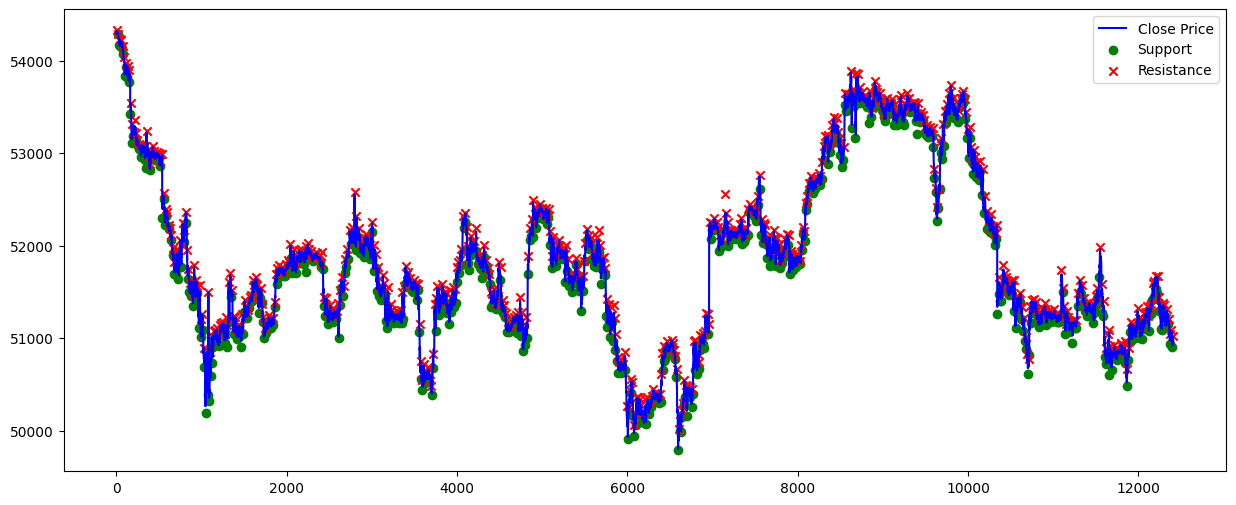

In [120]:
# Create a copy of the support and resistance columns to avoid modifying the original DataFrame
support_filtered = processed_df['support'].replace(0.0, float('nan'))
resistance_filtered = processed_df['resistance'].replace(0.0, float('nan'))

# Create a larger figure
plt.figure(figsize=(15, 6))

# Plot the close price using the range of data for the x-axis
plt.plot(range(len(processed_df)), processed_df['close'], label='Close Price', color='blue')

# Plot the support and resistance points, excluding 0/0.0 values
plt.scatter(range(len(processed_df)), support_filtered, label='Support', color='green', marker='o')
plt.scatter(range(len(processed_df)), resistance_filtered, label='Resistance', color='red', marker='x')

# Add legend and show plot
plt.legend()
plt.show()

In [121]:
processed_df.columns

Index(['open', 'high', 'low', 'close', 'rsi', 'ema', 'atr', 'bb_upper',
       'bb_middle', 'bb_lower', 'hv', 'price_spread', 'candle_to_atr', 'hour',
       'day_of_week', 'roc', 'price_change', 'Target', 'Stop Loss',
       'resistance', 'support', 'adx', 'rsi_oscillation', 'compression_ratio',
       'market_regime', 'Signal'],
      dtype='object')

In [122]:
# Assuming `processed_df` is sorted by time
split_ratio = 0.8  # 80% training, 20% evaluation

# Calculate the split index
split_index = int(len(processed_df) * split_ratio)

# Create training and evaluation datasets
train_processed_df = processed_df.iloc[:split_index]
eval_processed_df = processed_df.iloc[split_index:]

print(len(train_processed_df), len(eval_processed_df))

9929 2483


In [123]:
class TradingEnvironment(gym.Env):
    def __init__(self, data, config):
        super(TradingEnvironment, self).__init__()
        self.data = data.to_numpy()
        self.columns = data.columns.tolist()

        # Remove the 'Signal' column for observations
        if 'Signal' in self.columns:
            self.signal_idx = self.columns.index('Signal')
            self.columns.remove('Signal')  # Exclude 'Signal' from columns
        else:
            self.signal_idx = None

        self.config = config
        self.window_size = config['window_size']
        self.current_step = 0
        self.done = False
        self.balance = float(config['initial_capital'])
        self.quantity = config['quantity']
        self.position = 0
        self.entry_price = 0.0
        self.target_price = 0.0
        self.stop_loss_price = 0.0
        self.brokerage = config['brokerage']
        self.trades_log = []
        self.holding_duration = 0
        self.rewards = []
        self.profit_streak = 0
        self.loss_streak = 0

        # Action Space: 0 = Hold, 1 = Buy, 2 = Sell
        self.action_space = spaces.Discrete(3)

        # Observation Space: Flattened data window
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(self.window_size, len(self.columns)), dtype=np.float32
        )

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = self.window_size
        self.done = False
        self.balance = float(self.config['initial_capital'])
        self.position = 0
        self.entry_price = 0.0
        self.target_price = 0.0
        self.stop_loss_price = 0.0
        self.trades_log = []
        self.holding_duration = 0
        self.rewards = []
        self.profit_streak = 0
        self.loss_streak = 0
        return self._get_state(), {}

    def _get_state(self):
        state = self.data[self.current_step - self.window_size:self.current_step]
        if self.signal_idx is not None:
            state = np.delete(state, self.signal_idx, axis=1)  # Remove 'Signal' column dynamically
        return state

    def step(self, action):
        price = self.data[self.current_step, self.columns.index('close')]
        target_points = self.data[self.current_step, self.columns.index('Target')]
        stop_loss_points = self.data[self.current_step, self.columns.index('Stop Loss')]
        signal = self.data[self.current_step, self.signal_idx] if self.signal_idx is not None else None
        market_regime = self.data[self.current_step, self.columns.index('market_regime')]

        reward = 0
        profit_loss = 0.0

        # Handle open positions
        if self.position != 0:
            self.holding_duration += 1
            if (self.position == 1 and price >= self.target_price) or (self.position == -1 and price <= self.target_price):
                captured_points = abs(self.target_price - self.entry_price)
                profit_loss = captured_points * self.quantity
                self.balance += profit_loss  # Add profit to balance
                reward += 100  # Reward for hitting the target
                self.profit_streak += 1
                self.loss_streak = 0
                self._log_trade(price, "Target Hit")
                self.position = 0
                self.holding_duration = 0

            elif (self.position == 1 and price <= self.stop_loss_price) or (self.position == -1 and price >= self.stop_loss_price):
                captured_points = abs(self.entry_price - self.stop_loss_price)
                profit_loss = -captured_points * self.quantity
                self.balance += profit_loss  # Subtract loss from balance
                reward -= 100  # Penalty for hitting stop loss
                self.loss_streak += 1
                self.profit_streak = 0
                self._log_trade(price, "Stop Loss Hit")
                self.position = 0
                self.holding_duration = 0

            # Reward for profit streaks
            if self.profit_streak > 0:
                reward += 20 * self.profit_streak  # Amplify reward for profit streaks
            elif self.loss_streak > 0:
                reward -= 20 * self.loss_streak  # Amplify penalty for loss streaks

            # Holding duration penalty
            if market_regime == 2:  # Volatile market
                reward -= 5 * self.holding_duration  # Heavier penalty for holding
            elif market_regime == 0: # Sideways market
                reward -= 2 * self.holding_duration

            # Market regime alignment
            if market_regime == 1:  # Trending
                if (self.position == 1 and signal == 1) or (self.position == -1 and signal == 2):
                    reward += 30  # Reward for trading with the trend
                else:
                    reward -= 30  # Penalty for contrarian trades
            elif market_regime == 2:  # Volatile
                if self.holding_duration > 5:  # Encourage quick exits
                    reward -= 20


        # Handle new actions
        if self.position == 0:
            if action == 1:  # Buy
                self.position = 1
                self.entry_price = price
                self.target_price = price + target_points
                self.stop_loss_price = price - stop_loss_points

                if signal == 1:
                    reward += 100
                elif signal == 2:
                    reward -= 200

            elif action == 2:  # Sell
                self.position = -1
                self.entry_price = price
                self.target_price = price - target_points
                self.stop_loss_price = price + stop_loss_points

                if signal == 2:
                    reward += 100
                elif signal == 1:
                    reward -= 200

            elif action == 0: # Hold
                if signal == 1 or signal == 2:
                    reward -= 50

        # Penalize overtrading or revenge trading
        if len(self.trades_log) > 1:
            last_trade = self.trades_log[-1]
            if last_trade['Status'] in ["Stop Loss Hit", "Target Hit"]:
                time_since_last_trade = self.current_step - last_trade['Exit Step']
                if time_since_last_trade < self.config['min_trade_gap']:
                    reward -= 20  # Penalty for revenge trading

        # Update simulation
        self.current_step += 1
        if self.current_step >= len(self.data) or self.balance <= 0:
            self.done = True

        self.rewards.append(reward)
        info = {
            'Entry Price': self.entry_price,
            'Current Price': price,
            'Target Price': f"{self.target_price} ({target_points})",
            'Stop Loss Price': f"{self.stop_loss_price} ({stop_loss_points})",
            'Holding Duration': self.holding_duration,
            'Position': self.position,
            'Profit Streak': self.profit_streak,
            'Loss Streak': self.loss_streak,
            'Balance': self.balance,
            'Profit/Loss': profit_loss,
            'Reward': reward,
        }
        return self._get_state(), reward, self.done, False, info

    def _log_trade(self, price, status):
        entry_type = "Buy" if self.position == 1 else "Sell" if self.position == -1 else "hold"
        self.trades_log.append({
            'Entry Type': entry_type,
            'Entry Price': self.entry_price,
            'Exit Price': price,
            'Target Price': self.target_price,
            'Stop Loss Price': self.stop_loss_price,
            'Holding Duration': self.holding_duration,
            'Status': status,
            'Signal': self.data[self.current_step, self.signal_idx] if self.signal_idx is not None else None,
            'Exit Step': self.current_step
        })

    def get_trade_logs(self):
        return pd.DataFrame(self.trades_log)

    def calculate_metrics(self):
        sharpe_ratio = 0.0
        profit_factor = 0.0
        win_rate = 0.0

        if (len(self.trades_log) > 0):
            pnl = [t['Exit Price'] - t['Entry Price'] if t['Status'] == "Target Hit" else t['Entry Price'] - t['Exit Price'] for t in self.trades_log]
            pnl = np.array(pnl)

            # Sharpe Ratio
            mean_return = np.mean(pnl)
            std_return = np.std(pnl)
            sharpe_ratio = mean_return / std_return if std_return != 0 else 0

            # Profit Factor
            gross_profit = np.sum(pnl[pnl > 0])
            gross_loss = np.sum(-pnl[pnl < 0])
            profit_factor = gross_profit / gross_loss if gross_loss != 0 else np.inf

            # Win Rate
            wins = sum([1 for t in self.trades_log if t['Status'] == "Target Hit"])
            total_trades = len(self.trades_log)
            win_rate = (wins / total_trades) * 100 if total_trades > 0 else 0

        return {
            "Sharpe Ratio": sharpe_ratio,
            "Profit Factor": profit_factor,
            "Win Rate": win_rate
        }

    def print_trade_summary(self):
        metrics = self.calculate_metrics()
        print(f"\nFinal Balance: {self.balance:.2f}")
        print(f"Total Trades: {len(self.trades_log)}")
        print(f"Profitable Trades: {sum([1 for t in self.trades_log if t['Status'] == 'Target Hit'])}")
        print(f"Sharpe Ratio: {metrics['Sharpe Ratio']:.2f}")
        print(f"Profit Factor: {metrics['Profit Factor']:.2f}")
        print(f"Win Rate: {metrics['Win Rate']:.2f}%")

    def render(self, mode='human'):
        print(f"Step: {self.current_step}, Balance: {self.balance:.2f}, Position: {self.position}")

    def close(self):
        pass

In [124]:
# Configuration
config = {
    'window_size': 10,
    'initial_capital': 10000,
    'quantity': quantity,
    'min_trade_gap': 5,
    'brokerage': 20,
}

# Check for GPU availability and set memory growth
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        device = 'cuda'  # Use GPU
    except RuntimeError as e:
        print(e)
        device = 'cpu'
else:
    device = 'cpu'  # Fall back to CPU
print(f"Training will use {'GPU' if gpus else 'CPU'}.")

Training will use CPU.


Version 1

In [125]:
import os
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv

# Define paths for saving models
model_save_path = "ppo_trading_model"
tensorboard_log_dir = "./ppo_tensorboard"

# Ensure Tensorboard log directory exists
os.makedirs(tensorboard_log_dir, exist_ok=True)

def create_env(processed_df, config):
    """Create and return the trading environment."""
    return DummyVecEnv([lambda: TradingEnvironment(processed_df, config)])

def initialize_model(env):
    """Initialize a PPO model with predefined parameters."""
    return PPO(
        "MlpPolicy",          # Use MLP policy for numerical data
        env,                  # Environment to train the model
        verbose=1,            # Verbosity level for logging
        tensorboard_log=tensorboard_log_dir,  # Path for Tensorboard logs
        n_steps=2048,         # Number of steps per update
        batch_size=64,        # Batch size for optimization
        gamma=0.99,           # Discount factor
        learning_rate=3e-4,   # Learning rate
        clip_range=0.2,       # Clip range for PPO
        ent_coef=0.01,        # Entropy coefficient for exploration
        vf_coef=0.5,          # Value function coefficient
        max_grad_norm=0.5,    # Maximum gradient norm
    )

def load_or_train_model(env, total_timesteps):
    """Load an existing PPO model or train a new one."""
    if os.path.exists(model_save_path + ".zip"):
        print("Loading existing model...")
        model = PPO.load(model_save_path, env=env, device="cuda")
        print("Continuing training...")
    else:
        print("No existing model found. Training a new model...")
        model = initialize_model(env)

    model.learn(total_timesteps=total_timesteps)
    model.save(model_save_path)
    print(f"Model saved to {model_save_path}")
    return model

ppo_train_env = create_env(train_processed_df, config)

# Define the total timesteps for training
TOTAL_TIMESTEPS = 100000

# Load or train the model
ppo_model = load_or_train_model(ppo_train_env, TOTAL_TIMESTEPS)

Loading existing model...
Continuing training...
Logging to ./ppo_tensorboard/PPO_7
-----------------------------
| time/              |      |
|    fps             | 807  |
|    iterations      | 1    |
|    time_elapsed    | 2    |
|    total_timesteps | 2048 |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 600           |
|    iterations           | 2             |
|    time_elapsed         | 6             |
|    total_timesteps      | 4096          |
| train/                  |               |
|    approx_kl            | 0.00092858635 |
|    clip_fraction        | 0             |
|    clip_range           | 0.2           |
|    entropy_loss         | -0.848        |
|    explained_variance   | -1.19e-07     |
|    learning_rate        | 0.0003        |
|    loss                 | 6.33e+05      |
|    n_updates            | 500           |
|    policy_gradient_loss | -0.000242     |
| 

In [126]:
# Evaluation
print("Evaluating the PPO model...")
ppo_test_env = TradingEnvironment(eval_processed_df, config)
obs, _ = ppo_test_env.reset()
done = False
total_rewards = 0
while not done:
    action, _ = ppo_model.predict(obs, deterministic=True)
    obs, reward, done, _, info = ppo_test_env.step(action)
    total_rewards += reward
    ppo_test_env.render()

print(f"Total Rewards during Evaluation: {total_rewards}")

Evaluating the PPO model...
Step: 11, Balance: 10000.00, Position: 0
Step: 12, Balance: 10000.00, Position: 0
Step: 13, Balance: 10000.00, Position: 0
Step: 14, Balance: 10000.00, Position: 0
Step: 15, Balance: 10000.00, Position: 0
Step: 16, Balance: 10000.00, Position: 0
Step: 17, Balance: 10000.00, Position: 0
Step: 18, Balance: 10000.00, Position: 0
Step: 19, Balance: 10000.00, Position: 0
Step: 20, Balance: 10000.00, Position: 0
Step: 21, Balance: 10000.00, Position: 0
Step: 22, Balance: 10000.00, Position: 0
Step: 23, Balance: 10000.00, Position: 0
Step: 24, Balance: 10000.00, Position: 0
Step: 25, Balance: 10000.00, Position: 0
Step: 26, Balance: 10000.00, Position: 0
Step: 27, Balance: 10000.00, Position: 0
Step: 28, Balance: 10000.00, Position: 0
Step: 29, Balance: 10000.00, Position: 0
Step: 30, Balance: 10000.00, Position: 0
Step: 31, Balance: 10000.00, Position: 0
Step: 32, Balance: 10000.00, Position: 0
Step: 33, Balance: 10000.00, Position: 0
Step: 34, Balance: 10000.00, 

In [127]:
ppo_test_env.print_trade_summary()


Final Balance: 10000.00
Total Trades: 0
Profitable Trades: 0
Sharpe Ratio: 0.00
Profit Factor: 0.00
Win Rate: 0.00%


In [128]:
ppo_test_env.get_trade_logs()

""


In [131]:
# Variables to track streaks
max_profit_streak = 0
max_loss_streak = 0
current_profit_streak = 0
current_loss_streak = 0

# Check if 'Status' column exists
trade_logs = ppo_test_env.get_trade_logs()
if "Status" in trade_logs.columns:
    # Check if both 'Target Hit' and 'Stop Loss Hit' exist in the Status column
    if trade_logs["Status"].str.contains("Target Hit").any() and trade_logs["Status"].str.contains("Stop Loss Hit").any():
        # Iterate through the 'Status' column
        for status in trade_logs["Status"]:
            if status == "Target Hit":
                current_profit_streak += 1
                current_loss_streak = 0
            elif status == "Stop Loss Hit":
                current_loss_streak += 1
                current_profit_streak = 0
            else:
                current_profit_streak = 0
                current_loss_streak = 0

            # Update max streaks
            max_profit_streak = max(max_profit_streak, current_profit_streak)
            max_loss_streak = max(max_loss_streak, current_loss_streak)

        # Print the results
        print(f"Highest Profit Streak (Target Hit): {max_profit_streak}")
        print(f"Highest Loss Streak (Stop Loss Hit): {max_loss_streak}")
    else:
        print("The 'Status' column does not contain 'Target Hit' or 'Stop Loss Hit' values.")
else:
    print("The 'Status' column does not exist in the trade logs.")

The 'Status' column does not exist in the trade logs.


In [132]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, clear_output
import time

def visualize_trades_matplotlib(env, data):
    trades = env.get_trade_logs()
    close_prices = data['close'].values

    # Initialize the figure and axis
    fig, ax = plt.subplots(figsize=(14, 7))

    # Plot for the price line
    line, = ax.plot([], [], label='Close Price', color='blue')

    # Entry and exit markers
    entry_marker, = ax.plot([], [], 'o', color='orange', markersize=8, label='Entry')
    target_marker, = ax.plot([], [], '^', color='green', markersize=10, label='Target Hit')
    stop_loss_marker, = ax.plot([], [], 'v', color='red', markersize=10, label='Stop Loss Hit')

    # Set axis labels
    ax.set_title('Trade Visualization on Closing Price Chart')
    ax.set_xlabel('Steps')
    ax.set_ylabel('Price')

    # Add a legend
    ax.legend()

    # Set initial limits for the axes
    ax.set_xlim(0, 100)
    ax.set_ylim(np.min(close_prices) * 0.95, np.max(close_prices) * 1.05)

    # Update the plot dynamically
    for step in range(100, len(close_prices) + 1):
        # Update price line
        line.set_xdata(np.arange(step))
        line.set_ydata(close_prices[:step])

        # Add trade details dynamically
        entry_x, entry_y = [], []
        target_x, target_y = [], []
        stop_loss_x, stop_loss_y = [], []
        path_x, path_y = [], []
        path_colors = []  # List to store colors for each trade path

        for _, trade in trades.iterrows():
            entry_step = trade['Exit Step'] - trade['Holding Duration']
            exit_step = trade['Exit Step']

            if exit_step > step:
                continue

            # Collect entry points
            if entry_step <= step:
                entry_x.append(entry_step)
                entry_y.append(close_prices[entry_step])

            # Collect exit points
            if exit_step <= step:
                if trade['Status'] == 'Target Hit':
                    target_x.append(exit_step)
                    target_y.append(close_prices[exit_step])
                elif trade['Status'] == 'Stop Loss Hit':
                    stop_loss_x.append(exit_step)
                    stop_loss_y.append(close_prices[exit_step])

                # Add path points
                path_x.extend([entry_step, exit_step, None])
                path_y.extend([close_prices[entry_step], close_prices[exit_step], None])

                # Determine the path color based on the trade outcome
                if trade['Status'] == 'Target Hit':  # Profit
                    path_colors.extend(['green', 'green', 'none'])
                elif trade['Status'] == 'Stop Loss Hit':  # Loss
                    path_colors.extend(['red', 'red', 'none'])

        # Update entry, target, stop loss markers
        entry_marker.set_xdata(entry_x)
        entry_marker.set_ydata(entry_y)

        target_marker.set_xdata(target_x)
        target_marker.set_ydata(target_y)

        stop_loss_marker.set_xdata(stop_loss_x)
        stop_loss_marker.set_ydata(stop_loss_y)

        # Update trade paths with dynamic colors
        for i in range(0, len(path_x), 3):
            ax.plot(path_x[i:i+2], path_y[i:i+2], color=path_colors[i], linestyle='--')

        # Adjust the visible range dynamically
        visible_close_prices = close_prices[max(0, step - 100):step]

        # Update y-axis range based on the current visible close prices
        y_min = np.min(visible_close_prices) * 1  # Tightened buffer around min price
        y_max = np.max(visible_close_prices) * 1  # Tightened buffer around max price

        # Update y-axis range dynamically, ensuring tighter scaling
        ax.set_ylim(y_min, y_max)

        # Update x-axis range to be consistent with visible steps
        ax.set_xlim(max(0, step - 100), step)

        # Display the updated chart
        clear_output(wait=True)
        display(fig)
        time.sleep(0.001)

# Example usage
#visualize_trades_matplotlib(test_env, processed_df)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Live Trading

In [133]:
def get_sleep_time(interval_minutes, market_start_hour=9, market_start_minute=15):
    now = datetime.now()
    market_start_time = now.replace(hour=market_start_hour, minute=market_start_minute, second=0, microsecond=0)

    if now < market_start_time:
        # If current time is before the market starts, set next_run_time to market start time
        next_run_time = market_start_time
    else:
        # Calculate the minutes since the market start time
        minutes_since_market_start = (now - market_start_time).total_seconds() // 60
        # Calculate the number of minutes to the next interval boundary
        minutes_to_next_interval = interval_minutes - (minutes_since_market_start % interval_minutes)
        # Calculate the next run time by adding these minutes to the current time
        next_run_time = (now + timedelta(minutes=minutes_to_next_interval)).replace(second=0, microsecond=0)

    # Calculate the sleep time in seconds
    sleep_time = (next_run_time - now).total_seconds()
    return sleep_time

In [134]:
def fetch_option_chain():
    while True:
        try:
            data = {
                "symbol": index_symbol,
                "strikecount": 2,
                "timestamp": ""
            }
            response = fyers.optionchain(data=data)

            if response is not None:
                return response
        except Exception as e:
            print(f"Error fetching Option Chain: {e}")
            time.sleep(active_order_sleep)

index_oc= fetch_option_chain()

pd.DataFrame(index_oc['data']['optionsChain'])

,ask,bid,description,ex_symbol,exchange,fp,fpch,fpchp,fyToken,ltp,ltpch,ltpchp,option_type,strike_price,symbol,oi,oich,oichp,prev_oi,volume
0,0.0,0.00,NIFTYBANK-INDEX,BANKNIFTY,NSE,51246.0,-614.2,-1.18,101000000026009,50988.80,-616.75,-1.20,,-1,NSE:NIFTYBANK-INDEX,NaN,NaN,NaN,NaN,NaN
1,683.2,676.50,NaN,NaN,NaN,NaN,NaN,NaN,101125013039529,673.95,205.75,43.94,PE,50800,NSE:BANKNIFTY25JAN50800PE,183990.0,-39645.0,-17.73,223635.0,1523070.0
2,1103.1,1090.45,NaN,NaN,NaN,NaN,NaN,NaN,101125013039528,1101.35,-408.20,-27.04,CE,50800,NSE:BANKNIFTY25JAN50800CE,112140.0,11700.0,11.65,100440.0,294480.0
3,722.0,715.00,NaN,NaN,NaN,NaN,NaN,NaN,101125013039531,722.00,224.35,45.08,PE,50900,NSE:BANKNIFTY25JAN50900PE,187005.0,10605.0,6.01,176400.0,1845525.0
4,1042.3,1033.05,NaN,NaN,NaN,NaN,NaN,NaN,101125013039530,1042.30,-399.50,-27.71,CE,50900,NSE:BANKNIFTY25JAN50900CE,116265.0,27315.0,30.71,88950.0,450180.0
5,768.6,757.70,NaN,NaN,NaN,NaN,NaN,NaN,101125013039533,757.70,230.10,43.61,PE,51000,NSE:BANKNIFTY25JAN51000PE,1102065.0,16455.0,1.52,1085610.0,6716985.0
6,987.0,976.85,NaN,NaN,NaN,NaN,NaN,NaN,101125013039532,987.00,-387.20,-28.18,CE,51000,NSE:BANKNIFTY25JAN51000CE,820575.0,281235.0,52.14,539340.0,3277185.0
7,809.0,803.50,NaN,NaN,NaN,NaN,NaN,NaN,101125013039535,809.00,247.60,44.10,PE,51100,NSE:BANKNIFTY25JAN51100PE,201675.0,-24060.0,-10.66,225735.0,2775645.0
8,931.0,925.00,NaN,NaN,NaN,NaN,NaN,NaN,101125013039534,921.50,-384.40,-29.44,CE,51100,NSE:BANKNIFTY25JAN51100CE,218910.0,80025.0,57.62,138885.0,1755285.0
9,860.0,851.40,NaN,NaN,NaN,NaN,NaN,NaN,101125013039537,851.40,254.80,42.71,PE,51200,NSE:BANKNIFTY25JAN51200PE,300720.0,-19830.0,-6.19,320550.0,3995520.0


In [135]:
def assign_ce_pe_option_symbols():
    symbol_oc = fetch_option_chain()

    if symbol_oc != None:
        # Convert the response data into a DataFrame
        oc_df = pd.DataFrame(symbol_oc['data']['optionsChain'])

        # Find the first 'CE' symbol from the top
        first_ce_symbol = None
        for index, row in oc_df.iterrows():
            if row['option_type'] == 'CE':
                first_ce_symbol = row['symbol']
                first_ce_strike = row['strike_price']
                break

        # Find the first 'PE' symbol from the bottom
        first_pe_symbol = None
        for index, row in oc_df[::-1].iterrows():  # Iterate in reverse
            if row['option_type'] == 'PE':
                first_pe_symbol = row['symbol']
                first_pe_strike = row['strike_price']
                break

        return first_ce_symbol, first_pe_symbol, first_ce_strike, first_pe_strike

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [136]:
def onmessage_ce(ce_message):
    global ce_ltp, index_ltp, unsubscribe_done
    try:
        if ce_message['symbol'] == ce_symbol:
            if "ltp" in ce_message:
                ce_ltp = ce_message["ltp"]
                ce_ltp = float(ce_ltp)

        elif ce_message['symbol'] == index_symbol:
            if "ltp" in ce_message:
                index_ltp = ce_message["ltp"]
                index_ltp = float(index_ltp)

        if sl_hit_condition and not unsubscribe_done:
            data_type = "SymbolUpdate"
            symbols_to_unsubscribe = [ce_symbol, index_symbol]
            fyers_socket.unsubscribe(symbols=symbols_to_unsubscribe, data_type=data_type)

            unsubscribe_done = True  # Set the flag to True after unsubscribing

            print(f"Unsubscribed {ce_symbol} & {index_symbol}")

    except Exception as e:
        print(f"Error (onMessageCE): {e}")


def onerror_ce(message):
    print("CE Error:", message)


def onclose_ce(message):
    print("CE Connection closed:", message)


def onopen_ce():

    # Specify the data type and symbols you want to subscribe to
    data_type = "SymbolUpdate"

    # Subscribe to the specified symbols and data type
    symbols = [ce_symbol, index_symbol]
    fyers_socket.subscribe(symbols=symbols, data_type=data_type)

    # Keep the socket running to receive real-time data
    fyers_socket.keep_running()

# Function to fetch and return the Call Option's Last Traded Price (LTP), strike, and symbol.
def ce_buy_sell_ltp():
    global buy_sell_checked, ce_symbol, ce_strike
    try:
        if not buy_sell_checked:
            buy_sell_checked = True

            print("Fetching CE Strike Price LTP")

            ce_symbol, pe_symbol, ce_strike, pe_strike = assign_ce_pe_option_symbols()

            if ce_symbol is not None and ce_strike is not None:
                # Create a FyersDataSocket instance with the provided parameters
                ce_socket_fyers = data_ws.FyersDataSocket(
                    access_token=ws_token,       # Access token in the format "appid:accesstoken"
                    log_path="",                     # Path to save logs. Leave empty to auto-create logs in the current directory.
                    litemode=True,                  # Lite mode disabled. Set to True if you want a lite response.
                    write_to_file=False,              # Save response in a log file instead of printing it.
                    reconnect=True,                  # Enable auto-reconnection to WebSocket on disconnection.
                    on_connect=onopen_ce,               # Callback function to subscribe to data upon connection.
                    on_close=onclose_ce,                # Callback function to handle WebSocket connection close events.
                    on_error=onerror_ce,                # Callback function to handle WebSocket errors.
                    on_message=onmessage_ce             # Callback function to handle incoming messages from the WebSocket.
                )

                # Establish a connection to the Fyers WebSocket
                ce_socket_fyers.connect()

    except Exception as e:
        print(f"Error fetching CE Buy/Sell LTP: {e}")

In [137]:
def onmessage_pe(pe_message):
    global pe_ltp, index_ltp, unsubscribe_done
    try:
        if pe_message['symbol'] == pe_symbol:
            if "ltp" in pe_message:
                pe_ltp = pe_message["ltp"]
                pe_ltp = float(pe_ltp)

        elif pe_message['symbol'] == index_symbol:
            if "ltp" in pe_message:
                index_ltp = pe_message["ltp"]
                index_ltp = float(index_ltp)

        if sl_hit_condition and not unsubscribe_done:
            data_type = "SymbolUpdate"
            symbols_to_unsubscribe = [pe_symbol, index_symbol]
            fyers_socket.unsubscribe(symbols=symbols_to_unsubscribe, data_type=data_type)

            unsubscribe_done = True  # Set the flag to True after unsubscribing

            print(f"Unsubscribed {pe_symbol} & {index_symbol}")

    except Exception as e:
        print(f"Error (onMessagePE): {e}")

def onerror_pe(message):
    print("PE Error:", message)


def onclose_pe(message):
    print("PE Connection closed:", message)


def onopen_pe():
    # Specify the data type and symbols you want to subscribe to
    data_type = "SymbolUpdate"

    # Subscribe to the specified symbols and data type
    symbols = [pe_symbol, index_symbol]
    fyers_socket.subscribe(symbols=symbols, data_type=data_type)

    # Keep the socket running to receive real-time data
    fyers_socket.keep_running()

# Function to fetch and return the Call Option's Last Traded Price (LTP), strike, and symbol.
def pe_buy_sell_ltp():
    global buy_sell_checked, pe_symbol, pe_strike
    try:
        if not buy_sell_checked:
            buy_sell_checked = True

            print("Fetching PE Strike Price LTP")

            ce_symbol, pe_symbol, ce_strike, pe_strike = assign_ce_pe_option_symbols()

            if pe_symbol is not None and pe_strike is not None:
                # Create a FyersDataSocket instance with the provided parameters
                pe_socket_fyers = data_ws.FyersDataSocket(
                    access_token=ws_token,       # Access token in the format "appid:accesstoken"
                    log_path="",                     # Path to save logs. Leave empty to auto-create logs in the current directory.
                    litemode=True,                  # Lite mode disabled. Set to True if you want a lite response.
                    write_to_file=False,              # Save response in a log file instead of printing it.
                    reconnect=True,                  # Enable auto-reconnection to WebSocket on disconnection.
                    on_connect=onopen_pe,               # Callback function to subscribe to data upon connection.
                    on_close=onclose_pe,                # Callback function to handle WebSocket connection close events.
                    on_error=onerror_pe,                # Callback function to handle WebSocket errors.
                    on_message=onmessage_pe             # Callback function to handle incoming messages from the WebSocket.
                )

                # Establish a connection to the Fyers WebSocket
                pe_socket_fyers.connect()

    except Exception as e:
        print(f"Error fetching CE Buy/Sell LTP: {e}")

In [138]:
def place_order(symbol):
    try:
        market_order_data = {
            "symbol": symbol,
            "qty": int(quantity),
            "type": 2,  # Market Order
            "side": 1,
            "productType": "INTRADAY",
            "limitPrice": 0,
            "stopPrice": 0,
            "validity": "DAY",
            "disclosedQty": 0,
            "offlineOrder":False
        }

        market_order_entry = fyers.place_order(data=market_order_data)

        if "id" in market_order_entry:
            market_order_id = market_order_entry["id"]
            market_order_message = market_order_entry["message"]
            print(f"{market_order_message}")

    except Exception as e:
        print(f"Error placing orders: {str(e)}")

In [139]:
def trail_order(symbol, stoploss):
    while True:
        try:
            stoploss = int(stoploss)
            pending_order = fyers.orderbook()

            matching_orders = [order for order in pending_order["orderBook"] if order["status"] == 6]

            modified_orders = 0

            for order in matching_orders:
                if order['symbol'] == symbol:
                    pending_order_id = order['id']
                    pending_order_side = order['side']
                    pending_order_side = int(pending_order_side)

                    if pending_order_side != 1:
                        data = {
                            "id": pending_order_id,
                            "type": 4,
                            "limitPrice": stoploss - 1,
                            "stopPrice": stoploss
                        }

                        modify = fyers.modify_order(data=data)
                        trail_message = modify["message"]
                        print(f"{trail_message}")

                        if trail_message == "Successfully modified order":
                            modified_orders += 1

            # Check if all matching orders are successfully modified
            if modified_orders == len(matching_orders):
                break

            time.sleep(active_order_sleep)

        except Exception as e:
            print("Error modifying order:" + str(e))

In [140]:
def exit_active_order(symbol):
    while True:
        try:
            data = {
                "id":f"{symbol}-INTRADAY"
            }

            exit_response = fyers.exit_positions(data=data)

            if ["message"] in exit_response:
                print(exit_response["message"])
                break

            time.sleep(active_order_sleep)

        except Exception as e:
            print(f"Error exiting Order: {e}")

In [141]:
def reset_flags():
    global active_order, buy_sell_checked

    active_order = False
    buy_sell_checked = False

In [142]:
# Function to save profits and losses
def save_overall(overall_win, overall_loss, capital):
    trade_type = {
        "overall_win": overall_win,
        "overall_loss": overall_loss,
        "capital": capital
    }

    with open("trade_data.json", "w") as file:
        json.dump(trade_type, file)


# Function to load wins and losses
def load_overall():
    try:
        with open('trade_data.json') as file:
            return json.load(file)
    except FileNotFoundError:
        return None

In [143]:
def handle_active_ce_order():
    def ce_order_loop():
        global prev_ltp, target_inside, target_index_inside, trailing_sl_inside, trailing_index_inside, total_profit, total_loss, overall_win, overall_loss, ce_ltp, index_ltp, ce_strike, ce_symbol, sl_hit_condition, total_points, fixed_ltp, fixed_index_ltp, target, trailing_sl

        profit_money = 0
        overall_win = 0
        overall_loss = 0
        capital = 0
        profit_percentage = 0
        loss_percentage = 0

        ce_ltp_array = []
        index_ltp_array = []

        target_hit_once = False

        while True:
            try:
                if ce_ltp != 0 and index_ltp != 0:
                    ce_ltp_array.append(ce_ltp)
                    index_ltp_array.append(index_ltp)

                    trade_data = load_overall()

                    if trade_data:
                        overall_win = trade_data["overall_win"]
                        overall_loss = trade_data["overall_loss"]
                        capital = trade_data["capital"]

                    total_trades = overall_win + overall_loss

                    if overall_win > 0:
                        profit_percentage = (overall_win/total_trades) * 100
                        profit_percentage = round(profit_percentage, 2)

                    if overall_loss > 0:
                        loss_percentage = (overall_loss/total_trades) * 100
                        loss_percentage = round(loss_percentage, 2)


                    if index_ltp <= trailing_index_inside:
                        pygame.mixer.music.play()

                        #exit_active_order(ce_symbol)

                        points = int(ce_ltp) - int(fixed_ltp)

                        total_points = total_points + points

                        if points > 0:
                            total_profit += 1
                            overall_win += 1
                            total_trades = overall_win + overall_loss

                            if overall_win > 0:
                                profit_percentage = (overall_win/total_trades) * 100
                                profit_percentage = round(profit_percentage, 2)

                            if overall_loss > 0:
                                loss_percentage = (overall_loss/total_trades) * 100
                                loss_percentage = round(loss_percentage, 2)


                        elif points < 0:
                            total_loss += 1
                            overall_loss += 1
                            total_trades = overall_win + overall_loss

                            if overall_win > 0:
                                profit_percentage = (overall_win/total_trades) * 100
                                profit_percentage = round(profit_percentage, 2)

                            if overall_loss > 0:
                                loss_percentage = (overall_loss/total_trades) * 100
                                loss_percentage = round(loss_percentage, 2)

                        profit_money = points*quantity
                        capital = (capital + profit_money) - brokerage
                        save_overall(overall_win, overall_loss, capital)

                        # Apply dark background style to Matplotlib
                        plt.style.use('dark_background')

                        # Plotting
                        clear_output(wait=True)

                        plt.figure(figsize=(14, 7))

                        # Plot LTP data with labels
                        plt.plot(ce_ltp_array, label=f"LTP: {ce_ltp}", color='white')
                        plt.axhline(y=fixed_ltp, color='blue', linestyle='--', label=f'Entry LTP: {fixed_ltp}')
                        plt.axhline(y=target_inside, color='green', linestyle='-', label=f'Target: {target_inside}')
                        plt.axhline(y=trailing_sl_inside, color='red', linestyle='-', label=f'SL: {trailing_sl_inside}')

                        # Set labels and title
                        plt.xlabel("Time", color='white')
                        plt.ylabel("LTP", color='white')
                        plt.title("CE Order LTP Chart", color='white')

                        # Customize legend
                        plt.legend(facecolor='black')

                        # Remove grid lines
                        plt.grid(False)

                        # Display profit/loss information as text annotations
                        plt.text(0.02, 0.95, f"Total Profit: {total_profit}", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                        plt.text(0.02, 0.90, f"Total Loss: {total_loss}", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                        plt.text(0.02, 0.85, f"Points Captured: {total_points}", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                        plt.text(0.02, 0.80, f"Profit/Loss: {profit_money}", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                        plt.text(0.02, 0.75, f"Overall Profit: {overall_win} / {profit_percentage}%", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                        plt.text(0.02, 0.70, f"Overall Loss: {overall_loss} / {loss_percentage}%", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                        plt.text(0.02, 0.65, f"Capital: {capital}", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')

                        # Display the plot
                        display(plt.gcf())
                        plt.close()

                        # Apply dark background style to Matplotlib
                        plt.style.use('dark_background')

                        # Plotting
                        plt.figure(figsize=(14, 7))

                        # Plot LTP data with labels
                        plt.plot(index_ltp_array, label=f"LTP: {index_ltp}", color='white')
                        plt.axhline(y=fixed_index_ltp, color='blue', linestyle='--', label=f'Entry LTP: {fixed_index_ltp}')
                        plt.axhline(y=target_index_inside, color='green', linestyle='-', label=f'Target: {target_index_inside}')
                        plt.axhline(y=trailing_index_inside, color='red', linestyle='-', label=f'SL: {trailing_index_inside}')

                        # Set labels and title
                        plt.xlabel("Time", color='white')
                        plt.ylabel("LTP", color='white')
                        plt.title("Index LTP Chart", color='white')

                        # Customize legend
                        plt.legend(facecolor='black')

                        # Remove grid lines
                        plt.grid(False)

                        # Display the plot
                        display(plt.gcf())
                        plt.close()

                        sl_hit_condition = True

                        reset_flags()

                        break

                    elif index_ltp >= target_index_inside:
                        pygame.mixer.music.play()

                        if not target_hit_once:
                            target_hit_once = True
                            target /= 2
                            stop_loss =  trailing_sl / 10

                            target_inside = int(ce_ltp + target)
                            target_index_inside = int(index_ltp + target)

                            trailing_sl_inside = int(ce_ltp - stop_loss)
                            trailing_index_inside = int(index_ltp - stop_loss)

                            trailing_sl /= 2
                            prev_ltp = trailing_index_inside

                        else:
                            target_inside = int(ce_ltp + target)
                            target_index_inside = int(index_ltp + target)

                    else:
                        if (index_ltp - prev_ltp) >= trailing_sl and target_hit_once:
                            pygame.mixer.music.play()

                            prev_ltp = index_ltp

                            trailing_sl_inside = int(ce_ltp - trailing_sl)
                            trailing_index_inside = int(index_ltp - trailing_sl)

                    # Apply dark background style to Matplotlib
                    plt.style.use('dark_background')

                    # Plotting
                    clear_output(wait=True)

                    plt.figure(figsize=(14, 7))

                    # Plot LTP data with labels
                    plt.plot(ce_ltp_array, label=f"LTP: {ce_ltp}", color='white')
                    plt.axhline(y=fixed_ltp, color='blue', linestyle='--', label=f'Entry LTP: {fixed_ltp}')
                    plt.axhline(y=target_inside, color='green', linestyle='-', label=f'Target: {target_inside}')
                    plt.axhline(y=trailing_sl_inside, color='red', linestyle='-', label=f'SL: {trailing_sl_inside}')

                    # Set labels and title
                    plt.xlabel("Time", color='white')
                    plt.ylabel("LTP", color='white')
                    plt.title("CE Order LTP Chart", color='white')

                    # Customize legend
                    plt.legend(facecolor='black')

                    # Remove grid lines
                    plt.grid(False)

                    # Display profit/loss information as text annotations
                    plt.text(0.02, 0.95, f"Total Profit: {total_profit}", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                    plt.text(0.02, 0.90, f"Total Loss: {total_loss}", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                    plt.text(0.02, 0.85, f"Points Captured: {total_points}", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                    plt.text(0.02, 0.80, f"Profit/Loss: {profit_money}", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                    plt.text(0.02, 0.75, f"Overall Profit: {overall_win} / {profit_percentage}%", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                    plt.text(0.02, 0.70, f"Overall Loss: {overall_loss} / {loss_percentage}%", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                    plt.text(0.02, 0.65, f"Capital: {capital}", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')

                    # Display the plot
                    display(plt.gcf())
                    plt.close()

                    # Apply dark background style to Matplotlib
                    plt.style.use('dark_background')

                    # Plotting
                    plt.figure(figsize=(14, 7))

                    # Plot LTP data with labels
                    plt.plot(index_ltp_array, label=f"LTP: {index_ltp}", color='white')
                    plt.axhline(y=fixed_index_ltp, color='blue', linestyle='--', label=f'Entry LTP: {fixed_index_ltp}')
                    plt.axhline(y=target_index_inside, color='green', linestyle='-', label=f'Target: {target_index_inside}')
                    plt.axhline(y=trailing_index_inside, color='red', linestyle='-', label=f'SL: {trailing_index_inside}')

                    # Set labels and title
                    plt.xlabel("Time", color='white')
                    plt.ylabel("LTP", color='white')
                    plt.title("Index LTP Chart", color='white')

                    # Customize legend
                    plt.legend(facecolor='black')

                    # Remove grid lines
                    plt.grid(False)

                    # Display the plot
                    display(plt.gcf())
                    plt.close()

                time.sleep(active_order_sleep)

            except Exception as e:
                print(f"Error: {e}")

    threading.Thread(target=ce_order_loop()).start()

In [144]:
def handle_active_pe_order():
    def pe_order_loop():
        global prev_ltp, target_inside, target_index_inside, trailing_sl_inside, trailing_index_inside, total_profit, total_loss, overall_win, overall_loss, pe_ltp, index_ltp, pe_strike, pe_symbol, sl_hit_condition, total_points, fixed_ltp, fixed_index_ltp, target, trailing_sl

        profit_money = 0
        overall_win = 0
        overall_loss = 0
        capital = 0
        profit_percentage = 0
        loss_percentage = 0

        pe_ltp_array = []
        index_ltp_array = []

        target_hit_once = False

        while True:
            try:
                if pe_ltp != 0 and index_ltp != 0:
                    pe_ltp_array.append(pe_ltp)
                    index_ltp_array.append(index_ltp)

                    trade_data = load_overall()

                    if trade_data:
                        overall_win = trade_data["overall_win"]
                        overall_loss = trade_data["overall_loss"]
                        capital = trade_data["capital"]

                    total_trades = overall_win + overall_loss

                    if overall_win > 0:
                        profit_percentage = (overall_win/total_trades) * 100
                        profit_percentage = round(profit_percentage, 2)

                    if overall_loss > 0:
                        loss_percentage = (overall_loss/total_trades) * 100
                        loss_percentage = round(loss_percentage, 2)

                    if index_ltp >= trailing_index_inside:
                        pygame.mixer.music.play()

                        #exit_active_order(pe_symbol)

                        points = int(pe_ltp) - int(fixed_ltp)

                        total_points = total_points + points

                        if points > 0:
                            total_profit += 1
                            overall_win += 1
                            total_trades = overall_win + overall_loss

                            if overall_win > 0:
                                profit_percentage = (overall_win/total_trades) * 100
                                profit_percentage = round(profit_percentage, 2)

                            if overall_loss > 0:
                                loss_percentage = (overall_loss/total_trades) * 100
                                loss_percentage = round(loss_percentage, 2)


                        elif points < 0:
                            total_loss += 1
                            overall_loss += 1
                            total_trades = overall_win + overall_loss

                            if overall_win > 0:
                                profit_percentage = (overall_win/total_trades) * 100
                                profit_percentage = round(profit_percentage, 2)

                            if overall_loss > 0:
                                loss_percentage = (overall_loss/total_trades) * 100
                                loss_percentage = round(loss_percentage, 2)

                        profit_money = points*quantity
                        capital = (capital + profit_money) - brokerage
                        save_overall(overall_win, overall_loss, capital)

                        # Apply dark background style to Matplotlib
                        plt.style.use('dark_background')

                        # Plotting
                        clear_output(wait=True)

                        plt.figure(figsize=(14, 7))

                        # Plot LTP data with labels
                        plt.plot(pe_ltp_array, label=f"LTP: {pe_ltp}", color='white')
                        plt.axhline(y=fixed_ltp, color='blue', linestyle='--', label=f'Entry LTP: {fixed_ltp}')
                        plt.axhline(y=target_inside, color='green', linestyle='-', label=f'Target: {target_inside}')
                        plt.axhline(y=trailing_sl_inside, color='red', linestyle='-', label=f'SL: {trailing_sl_inside}')

                        # Set labels and title
                        plt.xlabel("Time", color='white')
                        plt.ylabel("LTP", color='white')
                        plt.title("PE Order LTP Chart", color='white')

                        # Customize legend
                        plt.legend(facecolor='black')

                        # Remove grid lines
                        plt.grid(False)

                        # Display profit/loss information as text annotations
                        plt.text(0.02, 0.95, f"Total Profit: {total_profit}", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                        plt.text(0.02, 0.90, f"Total Loss: {total_loss}", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                        plt.text(0.02, 0.85, f"Points Captured: {total_points}", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                        plt.text(0.02, 0.80, f"Profit/Loss: {profit_money}", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                        plt.text(0.02, 0.75, f"Overall Profit: {overall_win} / {profit_percentage}%", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                        plt.text(0.02, 0.70, f"Overall Loss: {overall_loss} / {loss_percentage}%", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                        plt.text(0.02, 0.65, f"Capital: {capital}", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')

                        # Display the plot
                        display(plt.gcf())
                        plt.close()

                        # Apply dark background style to Matplotlib
                        plt.style.use('dark_background')

                        # Plotting
                        plt.figure(figsize=(14, 7))

                        # Plot LTP data with labels
                        plt.plot(index_ltp_array, label=f"LTP: {index_ltp_array}", color='white')
                        plt.axhline(y=fixed_index_ltp, color='blue', linestyle='--', label=f'Entry LTP: {fixed_index_ltp}')
                        plt.axhline(y=target_index_inside, color='green', linestyle='-', label=f'Target: {target_index_inside}')
                        plt.axhline(y=trailing_index_inside, color='red', linestyle='-', label=f'SL: {trailing_index_inside}')

                        # Set labels and title
                        plt.xlabel("Time", color='white')
                        plt.ylabel("LTP", color='white')
                        plt.title("Index LTP Chart", color='white')

                        # Customize legend
                        plt.legend(facecolor='black')

                        # Remove grid lines
                        plt.grid(False)

                        # Display the plot
                        display(plt.gcf())
                        plt.close()

                        sl_hit_condition = True

                        reset_flags()

                        break

                    elif index_ltp <= target_index_inside:
                        pygame.mixer.music.play()

                        if not target_hit_once:
                            target_hit_once = True
                            target /= 2
                            stop_loss =  trailing_sl / 10

                            target_inside = int(pe_ltp + target)
                            target_index_inside = int(index_ltp - target)

                            trailing_sl_inside = int(pe_ltp - stop_loss)
                            trailing_index_inside = int(index_ltp + stop_loss)

                            trailing_sl /= 2
                            prev_ltp = trailing_index_inside

                        else:
                            target_inside = int(pe_ltp + target)
                            target_index_inside = int(index_ltp - target)

                    else:
                        if (prev_ltp - index_ltp) >= trailing_sl and target_hit_once:
                            pygame.mixer.music.play()

                            prev_ltp = index_ltp

                            trailing_sl_inside = int(pe_ltp - trailing_sl)
                            trailing_index_inside = int(index_ltp + trailing_sl)

                    # Apply dark background style to Matplotlib
                    plt.style.use('dark_background')

                    # Plotting
                    clear_output(wait=True)

                    plt.figure(figsize=(14, 7))

                    # Plot LTP data with labels
                    plt.plot(pe_ltp_array, label=f"LTP: {pe_ltp}", color='white')
                    plt.axhline(y=fixed_ltp, color='blue', linestyle='--', label=f'Entry LTP: {fixed_ltp}')
                    plt.axhline(y=target_inside, color='green', linestyle='-', label=f'Target: {target_inside}')
                    plt.axhline(y=trailing_sl_inside, color='red', linestyle='-', label=f'SL: {trailing_sl_inside}')

                    # Set labels and title
                    plt.xlabel("Time", color='white')
                    plt.ylabel("LTP", color='white')
                    plt.title("PE Order LTP Chart", color='white')

                    # Customize legend
                    plt.legend(facecolor='black')

                    # Remove grid lines
                    plt.grid(False)

                    # Display profit/loss information as text annotations
                    plt.text(0.02, 0.95, f"Total Profit: {total_profit}", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                    plt.text(0.02, 0.90, f"Total Loss: {total_loss}", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                    plt.text(0.02, 0.85, f"Points Captured: {total_points}", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                    plt.text(0.02, 0.80, f"Profit/Loss: {profit_money}", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                    plt.text(0.02, 0.75, f"Overall Profit: {overall_win} / {profit_percentage}%", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                    plt.text(0.02, 0.70, f"Overall Loss: {overall_loss} / {loss_percentage}%", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                    plt.text(0.02, 0.65, f"Capital: {capital}", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')

                    # Display the plot
                    display(plt.gcf())
                    plt.close()

                    # Apply dark background style to Matplotlib
                    plt.style.use('dark_background')

                    # Plotting
                    plt.figure(figsize=(14, 7))

                    # Plot LTP data with labels
                    plt.plot(index_ltp_array, label=f"LTP: {index_ltp}", color='white')
                    plt.axhline(y=fixed_index_ltp, color='blue', linestyle='--', label=f'Entry LTP: {fixed_index_ltp}')
                    plt.axhline(y=target_index_inside, color='green', linestyle='-', label=f'Target: {target_index_inside}')
                    plt.axhline(y=trailing_index_inside, color='red', linestyle='-', label=f'SL: {trailing_index_inside}')

                    # Set labels and title
                    plt.xlabel("Time", color='white')
                    plt.ylabel("LTP", color='white')
                    plt.title("Index LTP Chart", color='white')

                    # Customize legend
                    plt.legend(facecolor='black')

                    # Remove grid lines
                    plt.grid(False)

                    # Display the plot
                    display(plt.gcf())
                    plt.close()

                time.sleep(active_order_sleep)

            except Exception as e:
                print(f"Error: {e}")

    threading.Thread(target=pe_order_loop()).start()

In [145]:
def ce_entry():
    threading.Thread(target=ce_buy_sell_ltp).start()

    def ce_entry_thread():
        global fixed_ltp, fixed_index_ltp, target_inside, target_index_inside, trailing_sl_inside, trailing_index_inside, active_order, prev_ltp

        pygame.mixer.music.play()

        while True:
            if ce_ltp != 0 and index_ltp !=0:
                prev_ltp = index_ltp
                temp_index_ltp = prev_ltp

                temp_ltp = ce_ltp

                target_inside = temp_ltp + target
                target_inside = int(target_inside)

                trailing_sl_inside = temp_ltp - trailing_sl
                trailing_sl_inside = int(trailing_sl_inside)

                target_index_inside = temp_index_ltp + target
                target_index_inside = int(target_index_inside)

                trailing_index_inside = temp_index_ltp - trailing_sl
                trailing_index_inside = int(trailing_index_inside)

                if target_inside <= 0:
                    target_inside = 0
                if trailing_sl_inside <= 0:
                    trailing_sl_inside = 0

                #place_order(ce_symbol)

                fixed_ltp = temp_ltp
                fixed_index_ltp = temp_index_ltp

                active_order = True

                handle_active_ce_order()

                break

            else:
                time.sleep(active_order_sleep)


    threading.Thread(target=ce_entry_thread()).start()

In [146]:
def pe_entry():
    threading.Thread(target=pe_buy_sell_ltp).start()

    def pe_entry_thread():
        global fixed_ltp, fixed_index_ltp, target_inside, target_index_inside, trailing_sl_inside, trailing_index_inside, active_order, prev_ltp

        pygame.mixer.music.play()

        while True:
            if pe_ltp != 0 and index_ltp !=0:
                prev_ltp = index_ltp
                temp_index_ltp = prev_ltp

                temp_ltp = pe_ltp

                target_inside = temp_ltp + target
                target_inside = int(target_inside)

                trailing_sl_inside = temp_ltp - trailing_sl
                trailing_sl_inside = int(trailing_sl_inside)

                target_index_inside = temp_index_ltp - target
                target_index_inside = int(target_index_inside)

                trailing_index_inside = temp_index_ltp + trailing_sl
                trailing_index_inside = int(trailing_index_inside)

                if target_inside <= 0:
                    target_inside = 0
                if trailing_sl_inside <= 0:
                    trailing_sl_inside = 0

                #place_order(pe_symbol)

                fixed_ltp = temp_ltp
                fixed_index_ltp = temp_index_ltp

                active_order = True

                handle_active_pe_order()

                break

            else:
                time.sleep(active_order_sleep)


    threading.Thread(target=pe_entry_thread()).start()

In [147]:
def market_entry_exit_logic(rf_final_pred, actual_closing_price, predicted_price, final_df):
    global sl_hit_condition, unsubscribe_done, ce_ltp, pe_ltp, index_ltp, fixed_ltp, fixed_index_ltp, prev_ltp, target_inside, target_index_inside, trailing_sl_inside, trailing_index_inside, ce_strike, pe_strike, ce_symbol, pe_symbol

    ce_ltp = 0
    pe_ltp  =0
    index_ltp = 0
    fixed_ltp = 0
    fixed_index_ltp = 0
    prev_ltp = 0
    target_inside = 0
    target_index_inside = 0
    trailing_sl_inside = 0
    trailing_index_inside = 0
    ce_strike = None
    pe_strike = None
    ce_symbol = None
    pe_symbol = None

    final_current_time = final_df.index[-1].time()

    # Ensure trading occurs only during market hours
    if dt_time(9, 15) <= final_current_time <= dt_time(15, 0):
        if action == 1 and not active_trade:  # Buy action
            print("Buy action detected by PPO model.")
            pygame.mixer.music.play()
            sl_hit_condition = False
            unsubscribe_done = False
            print(f"Making CE Position at {actual_closing_price}")
            ce_entry()  # Execute CE entry logic
        elif action == 2 and not active_trade:  # Sell action
            print("Sell action detected by PPO model.")
            pygame.mixer.music.play()
            sl_hit_condition = False
            unsubscribe_done = False
            print(f"Making PE Position at {actual_closing_price}")
            pe_entry()  # Execute PE entry logic
        elif action == 0:
            print("Hold action detected by PPO model. No trade executed.")

In [164]:
def fetch_and_prepare_final_data():
    final_df = fetch_candle_data(10)

    final_df = final_df.drop_duplicates(subset='datetime', keep='first')

    final_data_processor = DataProcessor(final_df, peak_length=peak_length, indicator_length=indicator_length, live_processing=True)

    final_processed_df = final_data_processor.process().df

    return final_processed_df

In [171]:
def find_local_extrema(df):
    order=5
    atr_multiplier=1.5
    min_distance=5

    # Find local maxima and minima
    local_max = argrelextrema(df['high'].values, np.greater_equal, order=order)[0]
    local_min = argrelextrema(df['low'].values, np.less_equal, order=order)[0]

    # Calculate the threshold based on ATR
    threshold = df['atr'] * atr_multiplier

    # Filter by significance
    significant_max = []
    significant_min = []

    for idx in local_max:
        if idx > order and idx < len(df) - order:
            high = df['high'].iloc[idx]
            if significant_min:
                low = df['low'].iloc[significant_min[-1]]
                if (high - low) > threshold.iloc[idx]:
                    significant_max.append(idx)
            else:
                significant_max.append(idx)

    for idx in local_min:
        if idx > order and idx < len(df) - order:
            low = df['low'].iloc[idx]
            if significant_max:
                high = df['high'].iloc[significant_max[-1]]
                if (high - low) > threshold.iloc[idx]:
                    significant_min.append(idx)
            else:
                significant_min.append(idx)

    # Ensure minimum distance
    def filter_by_distance(points, min_distance):
        filtered_points = []
        for i in range(len(points)):
            if not filtered_points or (points[i] - filtered_points[-1]) > min_distance:
                filtered_points.append(points[i])
        return filtered_points

    significant_max = filter_by_distance(significant_max, min_distance)
    significant_min = filter_by_distance(significant_min, min_distance)

    return significant_max, significant_min

In [172]:
def get_trendline(df, point1, point2, kind='high'):
    x = [point1, point2]
    if kind == 'high':
        y = df['high'].values[x]
    else:
        y = df['low'].values[x]
    coeffs = np.polyfit(x, y, 1)
    trendline = np.polyval(coeffs, range(len(df)))
    return trendline

NameError: name 'y_pred_ensemble_latest_original' is not defined

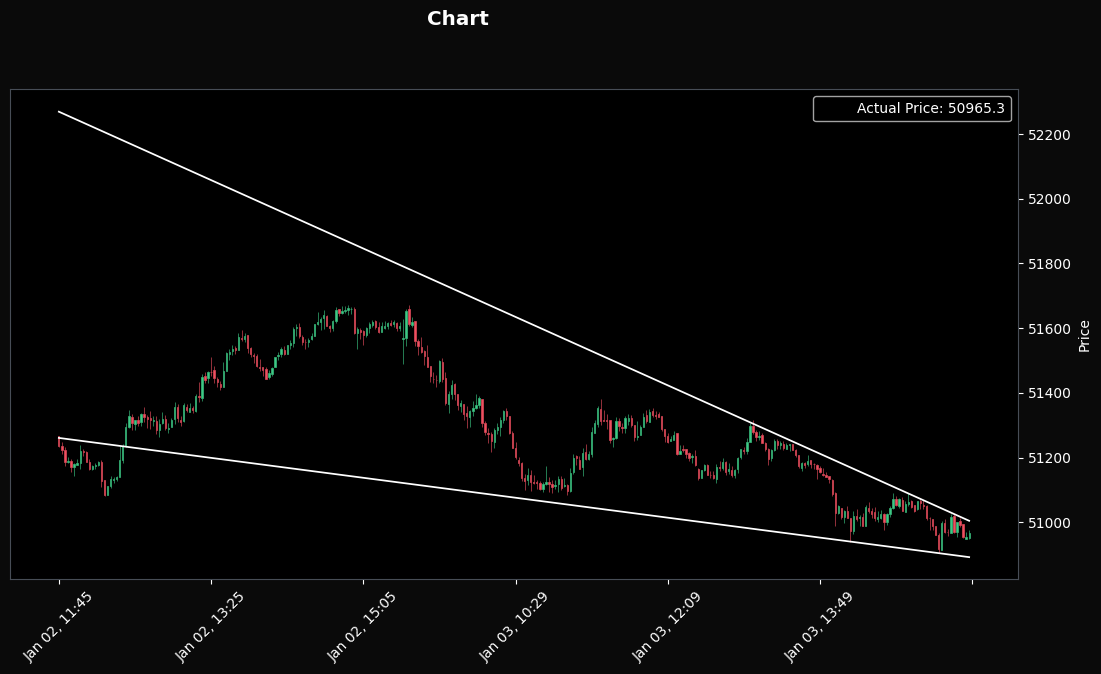

In [175]:
# Online training configuration
online_learning_steps = 1000  # Steps for each retraining
retrain_interval_minutes = 60  # Retrain the model every 60 minutes

start_time = datetime.now()

while True:
    clear_output(wait=True)

    num_candles = 300

    final_df = fetch_and_prepare_final_data()

    final_df = final_df.iloc[:-1]

    target = final_df['Target'].iloc[-1]
    trailing_sl = final_df['Stop Loss'].iloc[-1]

    # Initialize the TradingEnvironment with the latest data
    live_env = TradingEnvironment(final_df, config)
    obs, _ = live_env.reset()

    # Use PPO model to predict action for the latest data point
    action, _ = ppo_model.predict(obs, deterministic=True)

    # Extract the actual closing price
    actual_closing_price = final_df['close'].iloc[-1]

    # Retrain PPO model at specified intervals
    if (datetime.now() - start_time).seconds >= retrain_interval_minutes * 60:
        print("Retraining PPO model with online data...")
        train_env = TradingEnvironment(final_df, config)  # Create a new training environment
        ppo_model.set_env(train_env)  # Update the PPO model's environment
        ppo_model.learn(total_timesteps=online_learning_steps)  # Retrain the model
        ppo_model.save(model_save_path)  # Save the updated model
        start_time = datetime.now()

    # Identify most recent high and low points
    recent_highs, recent_lows = find_local_extrema(final_df)

    most_recent_high = recent_highs[-1] if len(recent_highs) > 1 else None
    most_recent_low = recent_lows[-1] if len(recent_lows) > 1 else None

    high_trendline = [np.nan] * len(final_df)
    low_trendline = [np.nan] * len(final_df)

    if most_recent_high is not None:
        previous_high = recent_highs[-2] if len(recent_highs) > 2 else most_recent_high
        high_trendline = get_trendline(final_df, previous_high, most_recent_high, kind='high')

    if most_recent_low is not None:
        previous_low = recent_lows[-2] if len(recent_lows) > 2 else most_recent_low
        low_trendline = get_trendline(final_df, previous_low, most_recent_low, kind='low')

    # Prepare candlestick data for mplfinance
    actual_candles = final_df[-num_candles:].copy()

    # Create a DataFrame for mplfinance
    mpf_df = actual_candles[['open', 'high', 'low', 'close']]

    # Create addplot elements for predicted prices and actual close prices
    ap = [
        mpf.make_addplot(final_df['close'][-num_candles:], color='none', panel=0, secondary_y=False, label=f"Actual Price: {final_df['close'].iloc[-1]}"),
        #mpf.make_addplot(y_pred_ensemble_final_plot, color=(0.95, 0.38, 0.25, 1), panel=0, secondary_y=False, label=f'Predicted Prices ({y_pred_ensemble_final_plot[-1]:.2f})')
    ]

    # Add trendlines to the plot
    if most_recent_high is not None:
        ap.append(mpf.make_addplot(high_trendline[-num_candles:], color='white', linestyle='-', panel=0, secondary_y=False))

    if most_recent_low is not None:
        ap.append(mpf.make_addplot(low_trendline[-num_candles:], color='white', linestyle='-', panel=0, secondary_y=False))

    fig, axlist = mpf.plot(mpf_df, type='candle', style='binancedark', volume=False, addplot=ap,
                        title=f'Chart', ylabel='Price',
                        figsize=(14, 7), returnfig=True)

    for ax in axlist:
        ax.grid(False)

    # Add the arrow for the future candle closing price
    last_closing_price = final_df['close'].iloc[-1]
    future_price = y_pred_ensemble_latest_original

    if future_price > last_closing_price:
        arrow_text = '↑'
        arrow_color = 'green'
    elif future_price < last_closing_price:
        arrow_text = '↓'
        arrow_color = 'red'
    else:
        arrow_text = 'x'
        arrow_color = 'white'

    axlist[0].annotate(
        arrow_text,
        (len(mpf_df), future_price),
        color=arrow_color,
        fontsize=20,
        fontweight='bold',
        ha='center'
    )
    axlist[0].legend()

    plt.show()

    # Execute market entry/exit logic
    market_entry_exit_logic(action, actual_closing_price, final_df, active_trade)

    sleep_time = get_sleep_time(interval_minutes)
    time.sleep(sleep_time)